<div align="center">


# <a href="https://ut.ac.ir/en" target="_parent">
  <img src="https://upload.wikimedia.org/wikipedia/fa/thumb/f/fd/University_of_Tehran_logo.svg/375px-University_of_Tehran_logo.svg.png"
       alt="School of Electrical and Computer Engineering"
       width="120" height="120"/>
</a>


# **Deep Learning (fall 2025)**



<br>  

**Fatemee Ghalami**  

**Insructor: Dr. Ahmad Kalhor**

<br>  


**University of Tehran**

College of Engineering

School of Electrical and Computer Engineering


<br>


</div>


In [1]:
!pip install -q torchmetrics torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 26.2 MB/s eta 0:00:00


In [19]:
import os
import glob
import time
import torch
import random
import zipfile
import warnings
import numpy as np
import pandas as pd
import torch.nn as nn
import nibabel as nib
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
import matplotlib.colors as mcolors

from torchinfo import summary
from tqdm.notebook import tqdm
from matplotlib.patches import Patch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [3]:
zip_path = '/content/drive/MyDrive/IBSR_nifti_stripped.zip'

extract_to = '/content/dataset_temp'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

root_dir = extract_to

root_dir = os.path.join(root_dir, 'IBSR_nifti_stripped')

In [4]:
def get_slice_data(volume_data, seg_data, axis, slice_idx):

    if axis == 0:
        vol_slice = volume_data[slice_idx, :, :]
        seg_slice = seg_data[slice_idx, :, :]
    elif axis == 1:
        vol_slice = volume_data[:, slice_idx, :]
        seg_slice = seg_data[:, slice_idx, :]
    else:
        vol_slice = volume_data[:, :, slice_idx]
        seg_slice = seg_data[:, :, slice_idx]

    vol_slice = np.squeeze(vol_slice)
    seg_slice = np.squeeze(seg_slice)

    vol_slice_rotated = np.rot90(vol_slice, k=1)
    seg_slice_rotated = np.rot90(seg_slice, k=1)

    return vol_slice_rotated, seg_slice_rotated

def pad_slice(vol_slice, seg_slice, target_dims=(256, 256)):

    h, w = vol_slice.shape
    th, tw = target_dims

    pad_h_top = (th - h) // 2
    pad_h_bottom = th - h - pad_h_top
    pad_w_left = (tw - w) // 2
    pad_w_right = tw - w - pad_w_left

    padding = ((max(0, pad_h_top), max(0, pad_h_bottom)),
               (max(0, pad_w_left), max(0, pad_w_right)))

    vol_padded = np.pad(vol_slice, padding, mode='constant', constant_values=0)
    seg_padded = np.pad(seg_slice, padding, mode='constant', constant_values=0)

    vol_padded = vol_padded[:th, :tw]
    seg_padded = seg_padded[:th, :tw]

    return vol_padded, seg_padded

class IBSRPatchDataset(Dataset):

    def __init__(self, volume_files, segmentation_files):
        self.patches = []
        self.masks = []
        self.patch_size = 128
        self.target_dims = (256, 256)
        self.slice_start = 10
        self.slice_stride = 3
        self.num_slices_to_extract = 48

        print("Loading and processing dataset (with rotation)...")
        for vol_path, seg_path in zip(volume_files, segmentation_files):
            try:
                vol_img = nib.load(vol_path)
                seg_img = nib.load(seg_path)

                vol_data = vol_img.get_fdata()
                seg_data = seg_img.get_fdata()

                for axis in range(3):
                    num_slices_in_axis = vol_data.shape[axis]

                    slice_indices = list(range(
                        self.slice_start,
                        num_slices_in_axis,
                        self.slice_stride
                    ))[:self.num_slices_to_extract]

                    for slice_idx in slice_indices:
                        vol_slice_rotated, seg_slice_rotated = get_slice_data(vol_data, seg_data, axis, slice_idx)

                        vol_padded, seg_padded = pad_slice(vol_slice_rotated, seg_slice_rotated, self.target_dims)

                        for x in [0, self.patch_size]:
                            for y in [0, self.patch_size]:
                                vol_patch = vol_padded[x : x + self.patch_size, y : y + self.patch_size]
                                seg_patch = seg_padded[x : x + self.patch_size, y : y + self.patch_size]

                                self.patches.append(vol_patch)
                                self.masks.append(seg_patch)
            except Exception as e:
                warnings.warn(f"Warning: Skipping file {vol_path} due to error: {e}")

        print(f"Dataset loaded. Total patches: {len(self.patches)}")

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        vol_patch = self.patches[idx].astype(np.float32)
        seg_patch = self.masks[idx].astype(np.int64)

        vol_patch_normalized = vol_patch

        vol_tensor = torch.tensor(vol_patch_normalized, dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(seg_patch, dtype=torch.long)

        return vol_tensor, mask_tensor

In [5]:
vol_files = sorted(glob.glob(os.path.join(root_dir, '**', 'IBSR_*_ana_strip.nii.gz'), recursive=True))
seg_files = sorted(glob.glob(os.path.join(root_dir, '**', 'IBSR_*_segTRI_fill_ana.nii.gz'), recursive=True))

print(f"Number of patients: {len(vol_files)}\n")

print("Summary of Data:")
print(f"{'Filename':<30} | {'Shape':<20} | {'Voxel Size':<20}")
print("-" * 127)
for f_path in vol_files:

    img = nib.load(f_path)

    fname = os.path.basename(f_path)
    shape = img.shape

    zooms = img.header.get_zooms()
    zooms_formatted = tuple([round(x, 2) for x in zooms])

    print(f"{fname:<30} | {str(shape):<20} | {str(zooms_formatted):<20}")
print("-" * 127)

Number of patients: 18

Summary of Data:
Filename                       | Shape                | Voxel Size          
-------------------------------------------------------------------------------------------------------------------------------
IBSR_01_ana_strip.nii.gz       | (256, 128, 256, 1)   | (np.float32(0.94), np.float32(1.5), np.float32(0.94), np.float32(0.0))
IBSR_02_ana_strip.nii.gz       | (256, 128, 256, 1)   | (np.float32(0.94), np.float32(1.5), np.float32(0.94), np.float32(0.0))
IBSR_03_ana_strip.nii.gz       | (256, 128, 256, 1)   | (np.float32(0.94), np.float32(1.5), np.float32(0.94), np.float32(0.0))
IBSR_04_ana_strip.nii.gz       | (256, 128, 256, 1)   | (np.float32(0.94), np.float32(1.5), np.float32(0.94), np.float32(0.0))
IBSR_05_ana_strip.nii.gz       | (256, 128, 256, 1)   | (np.float32(0.94), np.float32(1.5), np.float32(0.94), np.float32(0.0))
IBSR_06_ana_strip.nii.gz       | (256, 128, 256, 1)   | (np.float32(0.94), np.float32(1.5), np.float32(0.94), np.float3

In [6]:
train_vols = vol_files[:12]
train_segs = seg_files[:12]

val_vols = vol_files[12:]
val_segs = seg_files[12:]

print("Train Dataset:")
train_dataset = IBSRPatchDataset(train_vols, train_segs)
print("\nValidation Dataset:")
val_dataset = IBSRPatchDataset(val_vols, val_segs)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)


Train Dataset:
Loading and processing dataset (with rotation)...
Dataset loaded. Total patches: 6528

Validation Dataset:
Loading and processing dataset (with rotation)...
Dataset loaded. Total patches: 3264


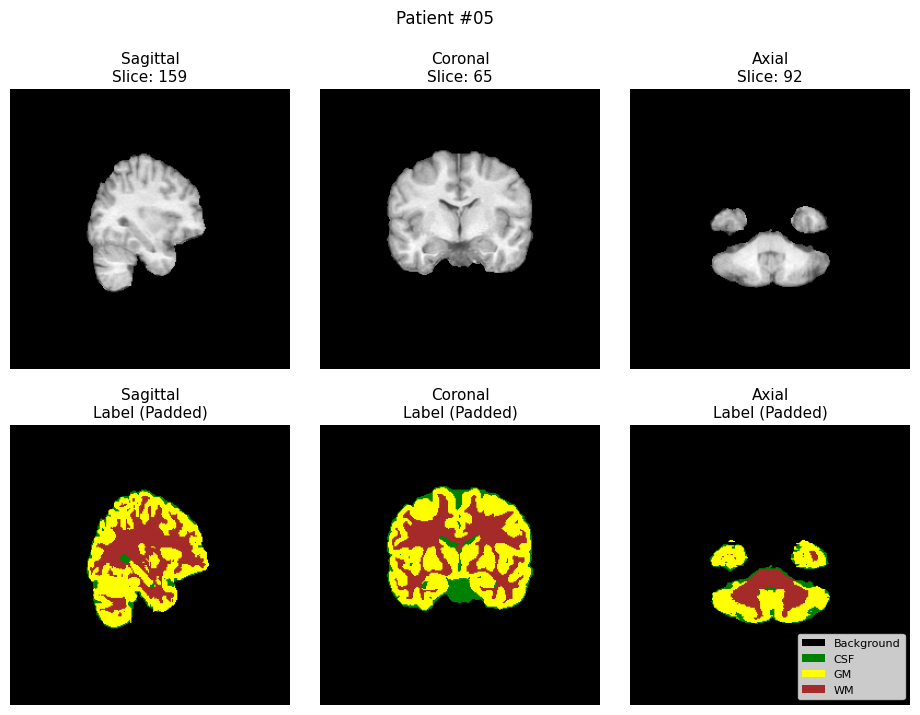

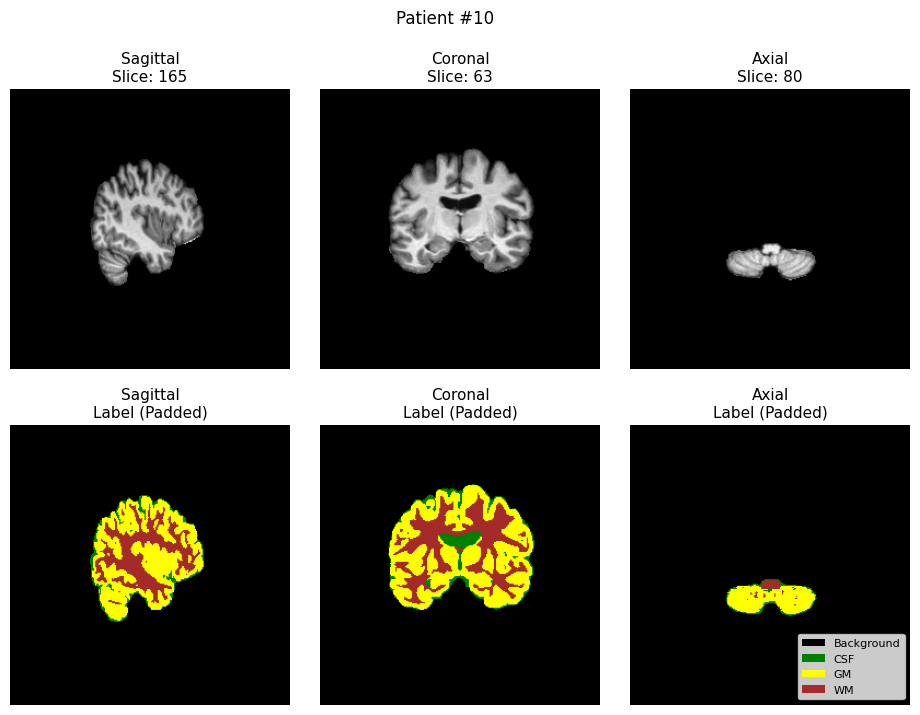

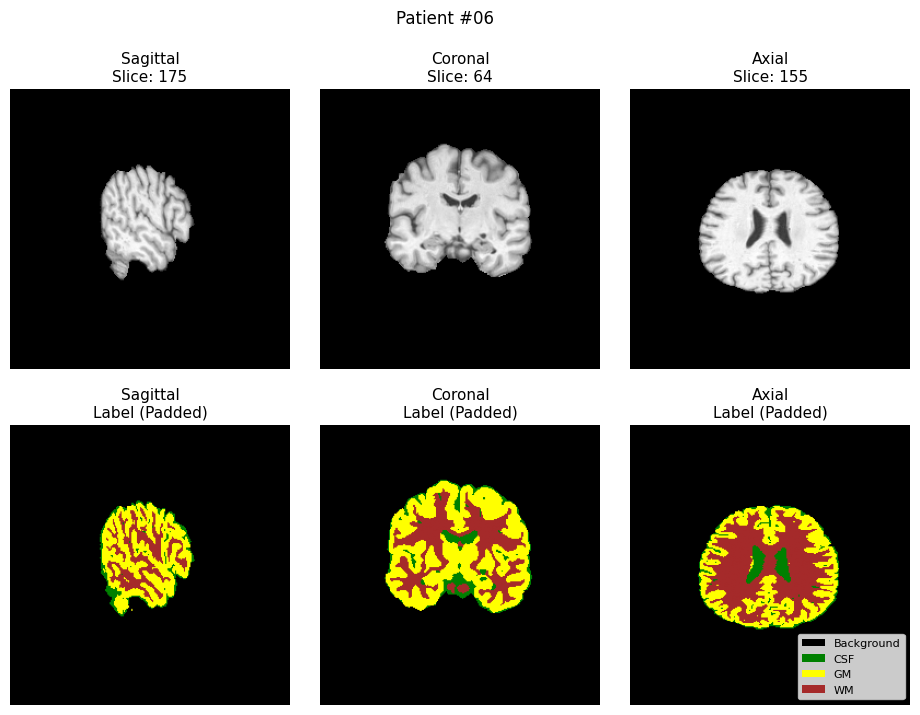

In [7]:
colors = ['black', 'green', 'yellow', 'brown']
cmap = mcolors.ListedColormap(colors)
bounds = [0, 1, 2, 3, 4]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

legend_elements = [
    Patch(facecolor='black', label='Background'),
    Patch(facecolor='green', label='CSF'),
    Patch(facecolor='yellow', label='GM'),
    Patch(facecolor='brown', label='WM')
]

def visualize_slices(vol_files, seg_files, num_patients=3):
    # random patient
    indices = random.sample(range(len(vol_files)), num_patients)

    for idx in indices:
        vol_path = vol_files[idx]
        seg_path = seg_files[idx]
        patient_id = os.path.basename(vol_path).split('_')[1]

        # load data
        vol_data = nib.load(vol_path).get_fdata()
        seg_data = nib.load(seg_path).get_fdata()

        # plot
        fig, axes = plt.subplots(2, 3, figsize=(12, 8))
        fig.suptitle(f"Patient #{patient_id}", fontsize=12)

        axis_names = ['Sagittal', 'Coronal', 'Axial']

        for axis in range(3):

            max_slices = vol_data.shape[axis]
            if max_slices > 127:
                slice_idx = random.randint(63, max_slices - 63)
            else:
                slice_idx = max_slices // 2

            raw_vol, raw_seg = get_slice_data(vol_data, seg_data, axis, slice_idx)
            padded_vol, padded_seg = pad_slice(raw_vol, raw_seg)

            # MRI data
            axes[0, axis].imshow(padded_vol, cmap='gray')
            axes[0, axis].set_title(f"{axis_names[axis]}\nSlice: {slice_idx}", fontsize=11)
            axes[0, axis].axis('off')

            # Mask
            axes[1, axis].imshow(padded_seg, cmap=cmap, norm=norm)
            axes[1, axis].set_title(f"{axis_names[axis]}\nLabel (Padded)", fontsize=11)
            axes[1, axis].axis('off')

        axes[1, 2].legend(handles=legend_elements, loc='lower right', fontsize=8)
        plt.subplots_adjust(wspace=0.001, hspace=0.2)
        # plt.tight_layout()
        plt.show()


visualize_slices(train_vols, train_segs, num_patients=3)


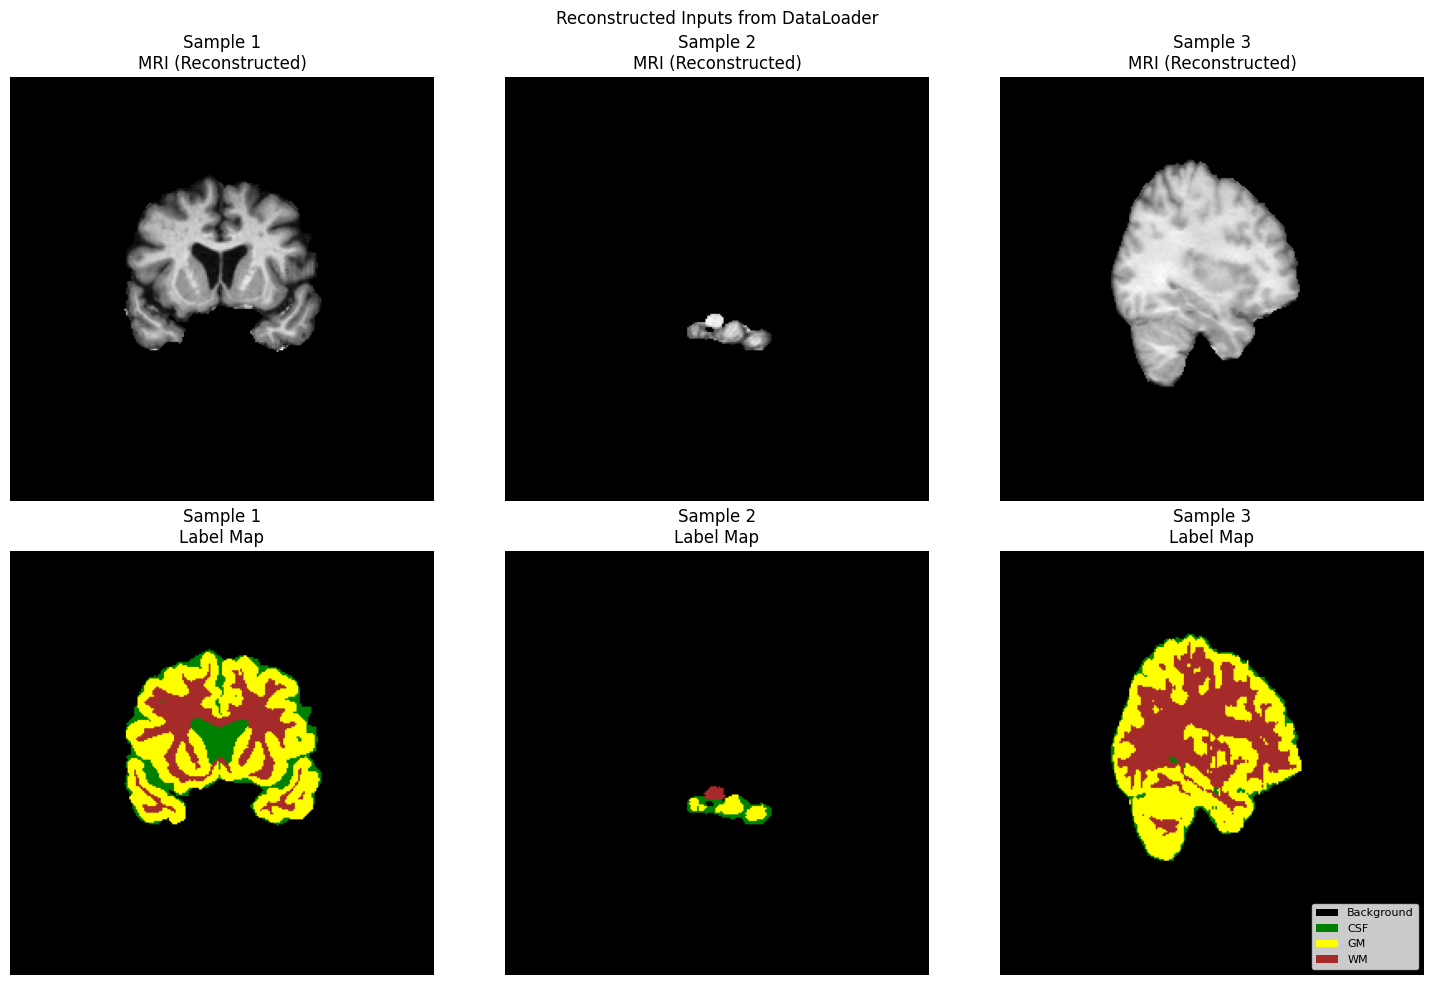

In [8]:
def visualize_reconstructed_samples(dataset):

    total_slices = len(dataset) // 4
    random_slice_indices = random.sample(range(total_slices), 3)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    plt.suptitle("Reconstructed Inputs from DataLoader")

    for col, slice_idx in enumerate(random_slice_indices):
        start_patch_idx = slice_idx * 4

        patches = []
        masks = []

        # 4 patches
        for i in range(4):
            img_tensor, mask_tensor = dataset[start_patch_idx + i]
            patches.append(img_tensor.squeeze().numpy())
            masks.append(mask_tensor.squeeze().numpy())

        # Stitching
        # [0] [1]
        # [2] [3]
        top_img = np.concatenate((patches[0], patches[1]), axis=1)
        bot_img = np.concatenate((patches[2], patches[3]), axis=1)
        full_img = np.concatenate((top_img, bot_img), axis=0)

        top_mask = np.concatenate((masks[0], masks[1]), axis=1)
        bot_mask = np.concatenate((masks[2], masks[3]), axis=1)
        full_mask = np.concatenate((top_mask, bot_mask), axis=0)

        axes[0, col].imshow(full_img, cmap='gray')
        axes[0, col].set_title(f"Sample {col+1}\nMRI (Reconstructed)", fontsize=12)
        axes[0, col].axis('off')

        axes[1, col].imshow(full_mask, cmap=cmap, norm=norm)
        axes[1, col].set_title(f"Sample {col+1}\nLabel Map", fontsize=12)
        axes[1, col].axis('off')

    axes[1, 2].legend(handles=legend_elements, loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.show()


visualize_reconstructed_samples(train_dataset)


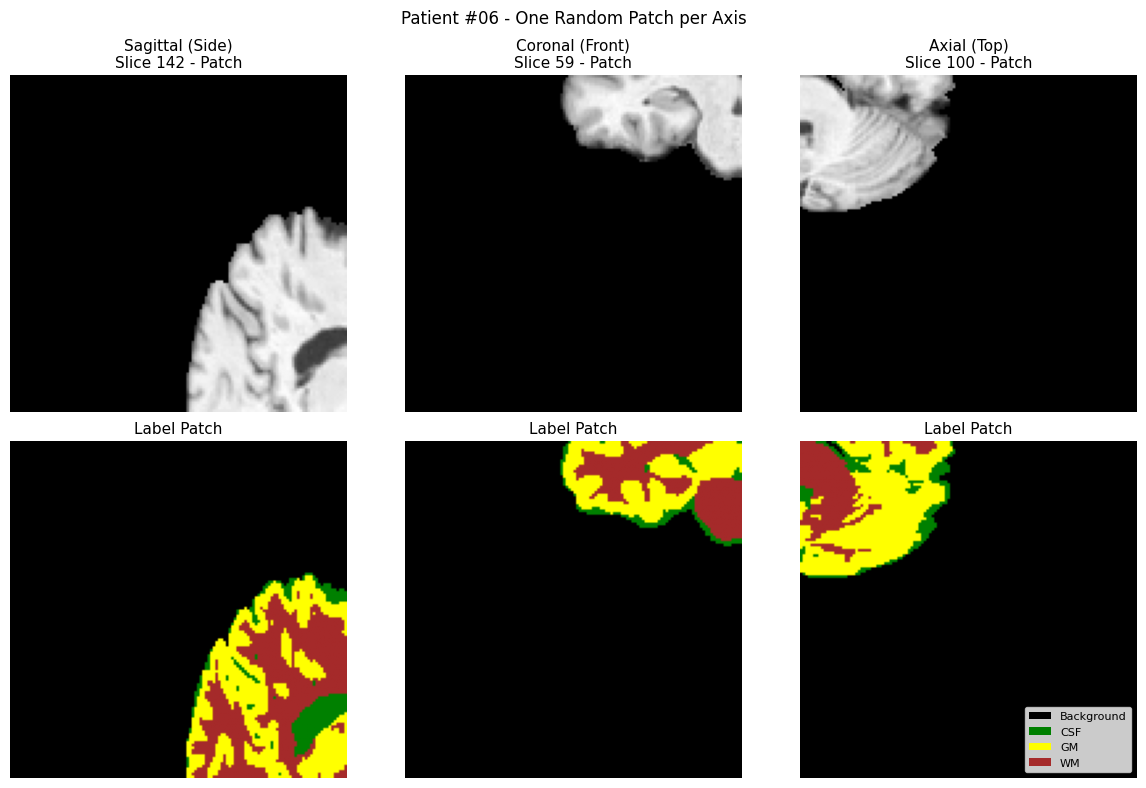

In [9]:
def visualize_one_patient_patches(vol_files, seg_files):

    idx = random.randint(0, len(vol_files) - 1)
    vol_path = vol_files[idx]
    seg_path = seg_files[idx]
    patient_id = os.path.basename(vol_path).split('_')[1]

    vol_data = nib.load(vol_path).get_fdata()
    seg_data = nib.load(seg_path).get_fdata()

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle(f"Patient #{patient_id} - One Random Patch per Axis")

    axis_names = ['Sagittal (Side)', 'Coronal (Front)', 'Axial (Top)']

    for axis in range(3):
        if axis == 0: sums = np.sum(seg_data, axis=(1, 2))
        elif axis == 1: sums = np.sum(seg_data, axis=(0, 2))
        else: sums = np.sum(seg_data, axis=(0, 1))

        valid_slices = np.where(sums > 500)[0]
        if len(valid_slices) > 0:
            slice_idx = random.choice(valid_slices)
        else:
            slice_idx = vol_data.shape[axis] // 2

        # Get ; Pad ; Patch
        raw_vol, raw_seg = get_slice_data(vol_data, seg_data, axis, slice_idx)
        padded_vol, padded_seg = pad_slice(raw_vol, raw_seg)

        sx = random.choice([0, 128])
        sy = random.choice([0, 128])

        patch_vol = padded_vol[sx:sx+128, sy:sy+128]
        patch_seg = padded_seg[sx:sx+128, sy:sy+128]

        # MRI
        axes[0, axis].imshow(patch_vol, cmap='gray')
        axes[0, axis].set_title(f"{axis_names[axis]}\nSlice {slice_idx} - Patch", fontsize=11)
        axes[0, axis].axis('off')

        # Mask
        axes[1, axis].imshow(patch_seg, cmap=cmap, norm=norm)
        axes[1, axis].set_title(f"Label Patch", fontsize=11)
        axes[1, axis].axis('off')


    axes[1, 2].legend(handles=legend_elements, loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.show()

visualize_one_patient_patches(train_vols, train_segs)


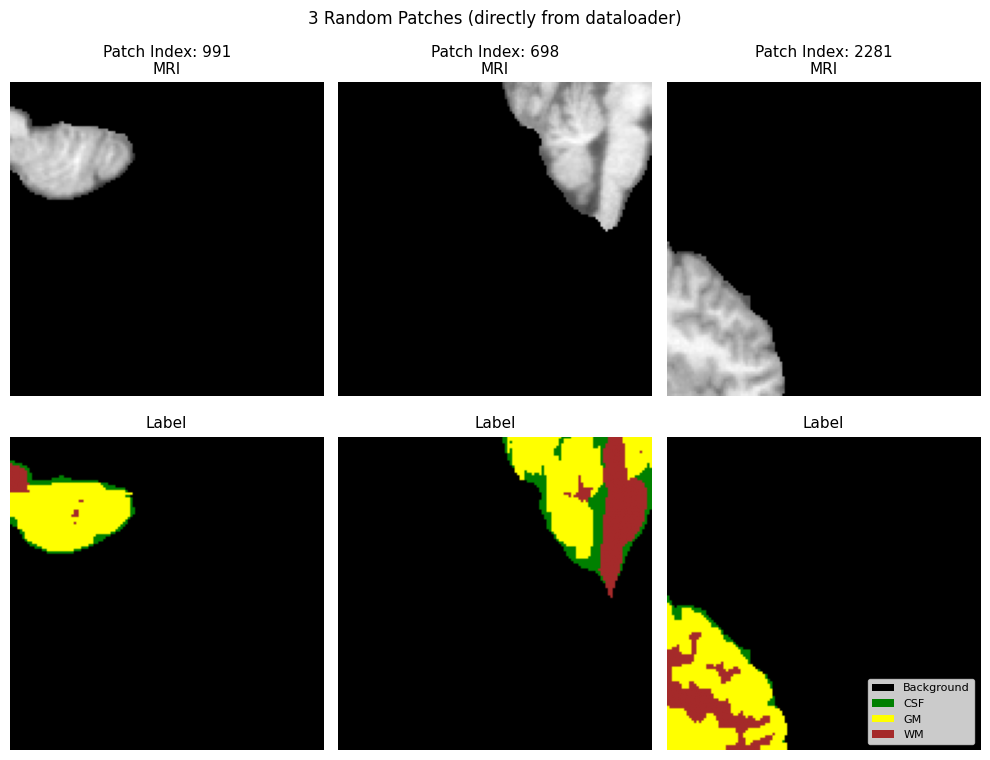

In [10]:
def visualize_random_patches(dataset, num_samples=3):

    valid_indices = []

    while len(valid_indices) < num_samples:
        idx = random.randint(0, len(dataset) - 1)
        _, mask_tensor = dataset[idx]

        if torch.sum(mask_tensor) > 100:
            if idx not in valid_indices:
                valid_indices.append(idx)


    fig, axes = plt.subplots(2, num_samples, figsize=(10, 8))
    fig.suptitle(f"3 Random Patches (directly from dataloader)")

    for i, idx in enumerate(valid_indices):
        img_tensor, mask_tensor = dataset[idx]

        img_np = img_tensor.squeeze().numpy()
        mask_np = mask_tensor.squeeze().numpy()

        # MRI Patch
        axes[0, i].imshow(img_np, cmap='gray')
        axes[0, i].set_title(f"Patch Index: {idx}\nMRI", fontsize=11)
        axes[0, i].axis('off')

        # Mask Patch
        axes[1, i].imshow(mask_np, cmap=cmap, norm=norm)
        axes[1, i].set_title(f"Label", fontsize=11)
        axes[1, i].axis('off')

    axes[1, num_samples-1].legend(handles=legend_elements, loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.show()

visualize_random_patches(train_dataset)


In [11]:
# Conv ; ReLU ; Conv ; ReLU
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super(ConvBlock, self).__init__()
        padding = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

# M-Net
class MNet(nn.Module):
    def __init__(self, num_classes=4):
        super(MNet, self).__init__()

        self.pool = nn.MaxPool2d(2, 2)

        # Encoder (Left Leg Integration)
        self.enc1 = ConvBlock(1, 64, kernel_size=1)
        self.enc2 = ConvBlock(64 + 1, 128, kernel_size=1)
        self.enc3 = ConvBlock(128 + 1, 256, kernel_size=1)
        self.enc4 = ConvBlock(256 + 1, 512, kernel_size=1)

        # Bottleneck
        self.bridge = ConvBlock(512, 1024, kernel_size=1)

        # Decoder (Up-Convolution)
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(1024, 512, kernel_size=3)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(512, 256, kernel_size=3)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(256, 128, kernel_size=3)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(128, 64, kernel_size=3)

        # Right Leg
        self.side_4 = nn.Conv2d(512, num_classes, kernel_size=1)
        self.side_3 = nn.Conv2d(256, num_classes, kernel_size=1)
        self.side_2 = nn.Conv2d(128, num_classes, kernel_size=1)
        self.side_1 = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Left Leg (Image Pyramid)
        x1 = x                      # 128x128
        x2 = self.pool(x1)          # 64x64
        x3 = self.pool(x2)          # 32x32
        x4 = self.pool(x3)          # 16x16

        # Encoder
        e1 = self.enc1(x1)
        e2 = self.enc2(torch.cat([self.pool(e1), x2], dim=1))
        e3 = self.enc3(torch.cat([self.pool(e2), x3], dim=1))
        e4 = self.enc4(torch.cat([self.pool(e3), x4], dim=1))

        # Bottleneck
        b = self.bridge(self.pool(e4))

        # Decoder
        d4_up = self.up4(b)
        d4 = self.dec4(torch.cat([d4_up, e4], dim=1))

        d3_up = self.up3(d4)
        d3 = self.dec3(torch.cat([d3_up, e3], dim=1))

        d2_up = self.up2(d3)
        d2 = self.dec2(torch.cat([d2_up, e2], dim=1))

        d1_up = self.up1(d2)
        d1 = self.dec1(torch.cat([d1_up, e1], dim=1))

        # Right Leg (Aggregation)

        out4 = self.side_4(d4) #  16x16
        out3 = self.side_3(d3) #  32x32
        out2 = self.side_2(d2) #  64x64
        out1 = self.side_1(d1) #  128x128

        out4 = F.interpolate(out4, size=x.shape[2:], mode='bilinear', align_corners=True)
        out3 = F.interpolate(out3, size=x.shape[2:], mode='bilinear', align_corners=True)
        out2 = F.interpolate(out2, size=x.shape[2:], mode='bilinear', align_corners=True)

        final_out = (out1 + out2 + out3 + out4) / 4

        return final_out

# test
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MNet(num_classes=4).to(device)

# dummy input
dummy = torch.randn(1, 1, 128, 128).to(device)
out = model(dummy)

print(f"output shape: {out.shape}")
print(f"number of trainable parameters: {count_parameters(model):,}")

summary(
    model,
    input_size=(1, 1, 128, 128),
    depth=2,
    col_names=["output_size", "num_params", "trainable"],
    row_settings=["var_names"]
)

output shape: torch.Size([1, 4, 128, 128])
number of trainable parameters: 14,290,320


Layer (type (var_name))                  Output Shape              Param #                   Trainable
MNet (MNet)                              [1, 4, 128, 128]          --                        True
├─MaxPool2d (pool)                       [1, 1, 64, 64]            --                        --
├─MaxPool2d (pool)                       [1, 1, 32, 32]            --                        --
├─MaxPool2d (pool)                       [1, 1, 16, 16]            --                        --
├─ConvBlock (enc1)                       [1, 64, 128, 128]         --                        True
│    └─Sequential (block)                [1, 64, 128, 128]         4,288                     True
├─MaxPool2d (pool)                       [1, 64, 64, 64]           --                        --
├─ConvBlock (enc2)                       [1, 128, 64, 64]          --                        True
│    └─Sequential (block)                [1, 128, 64, 64]          24,960                    True
├─MaxPool2d (pool)     

In [12]:
class SegmentationMetrics:
    def __init__(self, num_classes=4):
        self.num_classes = num_classes
        self.reset()

    def reset(self):

        self.tp = {i: 0 for i in range(self.num_classes)}
        self.fp = {i: 0 for i in range(self.num_classes)}
        self.fn = {i: 0 for i in range(self.num_classes)}

    def update(self, logits, targets):

        preds = torch.argmax(logits, dim=1)

        for cls in range(self.num_classes):
            p = (preds == cls)
            t = (targets == cls)

            self.tp[cls] += (p & t).sum().item()
            self.fp[cls] += (p & (~t)).sum().item()
            self.fn[cls] += ((~p) & t).sum().item()

    def compute(self):
        results = {}
        eps = 1e-6

        for cls in range(self.num_classes):
            dice = (2 * self.tp[cls]) / (2 * self.tp[cls] + self.fp[cls] + self.fn[cls] + eps)

            # Jaccard
            jaccard = self.tp[cls] / (self.tp[cls] + self.fp[cls] + self.fn[cls] + eps)

            # Precision
            precision = self.tp[cls] / (self.tp[cls] + self.fp[cls] + eps)

            # Recall
            recall = self.tp[cls] / (self.tp[cls] + self.fn[cls] + eps)

            results[cls] = {
                'Dice': dice,
                'Jaccard': jaccard,
                'Precision': precision,
                'Recall': recall
            }
        return results

# test
dummy_out = torch.randn(1, 4, 128, 128)
dummy_lbl = torch.randint(0, 4, (1, 128, 128))

metrics = SegmentationMetrics(num_classes=4)
metrics.update(dummy_out, dummy_lbl)
res = metrics.compute()

for cls, scores in res.items():
    print(f"class {cls}: Dice = {scores['Dice']:.4f}")

class 0: Dice = 0.2488
class 1: Dice = 0.2509
class 2: Dice = 0.2468
class 3: Dice = 0.2579


In [13]:
def lecun_initialization(m):

    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):

        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(m.weight)

        std = (1.0 / fan_in) ** 0.5

        nn.init.normal_(m.weight, mean=0.0, std=std)


In [14]:
model = MNet(num_classes=4).to(device)
model.apply(lecun_initialization)

optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.99)
criterion = nn.CrossEntropyLoss()
num_epochs = 10

history = {
    'train_loss': [], 'val_loss': [],
    'val_dice_csf': [], 'val_dice_gm': [], 'val_dice_wm': []
}

print("Training for 10 epochs..")

for epoch in range(num_epochs):
    epoch_start = time.time()

    # Train
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)

    for inputs, masks in pbar:
        inputs, masks = inputs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    epoch_train_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    val_running_loss = 0.0

    metrics = SegmentationMetrics(num_classes=4)

    with torch.no_grad():
        for inputs, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
            inputs, masks = inputs.to(device), masks.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, masks)
            val_running_loss += loss.item()

            metrics.update(outputs, masks)

    epoch_val_loss = val_running_loss / len(val_loader)

    final_scores = metrics.compute()

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_dice_csf'].append(final_scores[1]['Dice'])
    history['val_dice_gm'].append(final_scores[2]['Dice'])
    history['val_dice_wm'].append(final_scores[3]['Dice'])

    duration = time.time() - epoch_start
    print(f"Epoch {epoch+1}/{num_epochs} ({duration:.0f}s)")
    print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    print(f"Dice Scores: CSF: {final_scores[1]['Dice']:.4f} | GM: {final_scores[2]['Dice']:.4f} | WM: {final_scores[3]['Dice']:.4f}")
    print("")


Training for 10 epochs..


Epoch 1/10 [Train]:   0%|          | 0/6528 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/3264 [00:00<?, ?it/s]

Epoch 1/10 (130s)
Train Loss: 0.1016 | Val Loss: 0.0624
Dice Scores: CSF: 0.5319 | GM: 0.8361 | WM: 0.7859



Epoch 2/10 [Train]:   0%|          | 0/6528 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/3264 [00:00<?, ?it/s]

Epoch 9/10 (138s)
Train Loss: 0.0425 | Val Loss: 0.0513
Dice Scores: CSF: 0.5937 | GM: 0.8644 | WM: 0.8149



Epoch 10/10 [Train]:   0%|          | 0/6528 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/3264 [00:00<?, ?it/s]

Epoch 10/10 (137s)
Train Loss: 0.0420 | Val Loss: 0.0472
Dice Scores: CSF: 0.6186 | GM: 0.8895 | WM: 0.8020



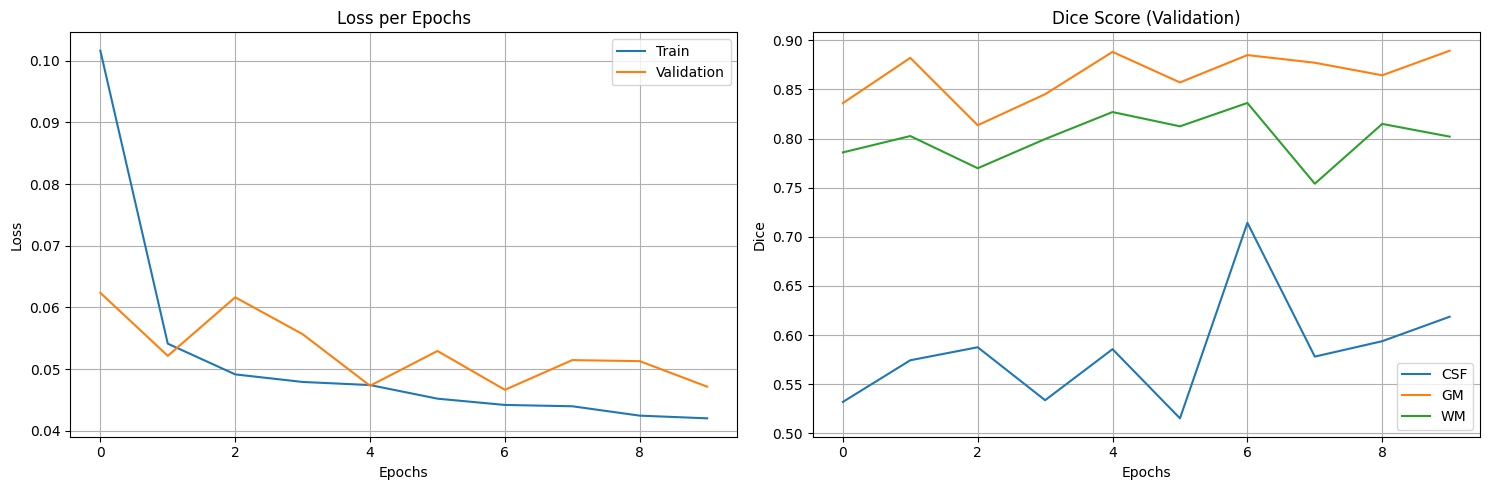

In [15]:
plt.figure(figsize=(15, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss per Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Dice
plt.subplot(1, 2, 2)
plt.plot(history['val_dice_csf'], label='CSF')
plt.plot(history['val_dice_gm'], label='GM')
plt.plot(history['val_dice_wm'], label='WM')

plt.title('Dice Score (Validation)')
plt.xlabel('Epochs')
plt.ylabel('Dice')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
print(f"Average CSF Dice: {np.mean(history['val_dice_csf']):.4f}")
print(f"Average GM Dice: {np.mean(history['val_dice_gm']):.4f}")
print(f"Average WM Dice: {np.mean(history['val_dice_wm']):.4f}")

Average CSF Dice: 0.5833
Average GM Dice: 0.8639
Average WM Dice: 0.8005


In [20]:
metrics = SegmentationMetrics(num_classes=4)

model.eval()

with torch.no_grad():
    for inputs, masks in tqdm(val_loader):
        inputs = inputs.to(device)
        masks = masks.to(device)

        outputs = model(inputs)
        metrics.update(outputs, masks)

final_results = metrics.compute()

df = pd.DataFrame(final_results).T
df.index = ['Background', 'CSF', 'GM', 'WM']
df = df.round(4)

print("\nFinal Results:")
display(df)

  0%|          | 0/3264 [00:00<?, ?it/s]


Final Results:


,Dice,Jaccard,Precision,Recall
Background,0.9994,0.9989,0.9989,1.0000
CSF,0.6186,0.4478,0.8603,0.4829
GM,0.8895,0.8009,0.8367,0.9493
WM,0.8020,0.6694,0.9127,0.7152


Slice number 25, patches: 100 to 103



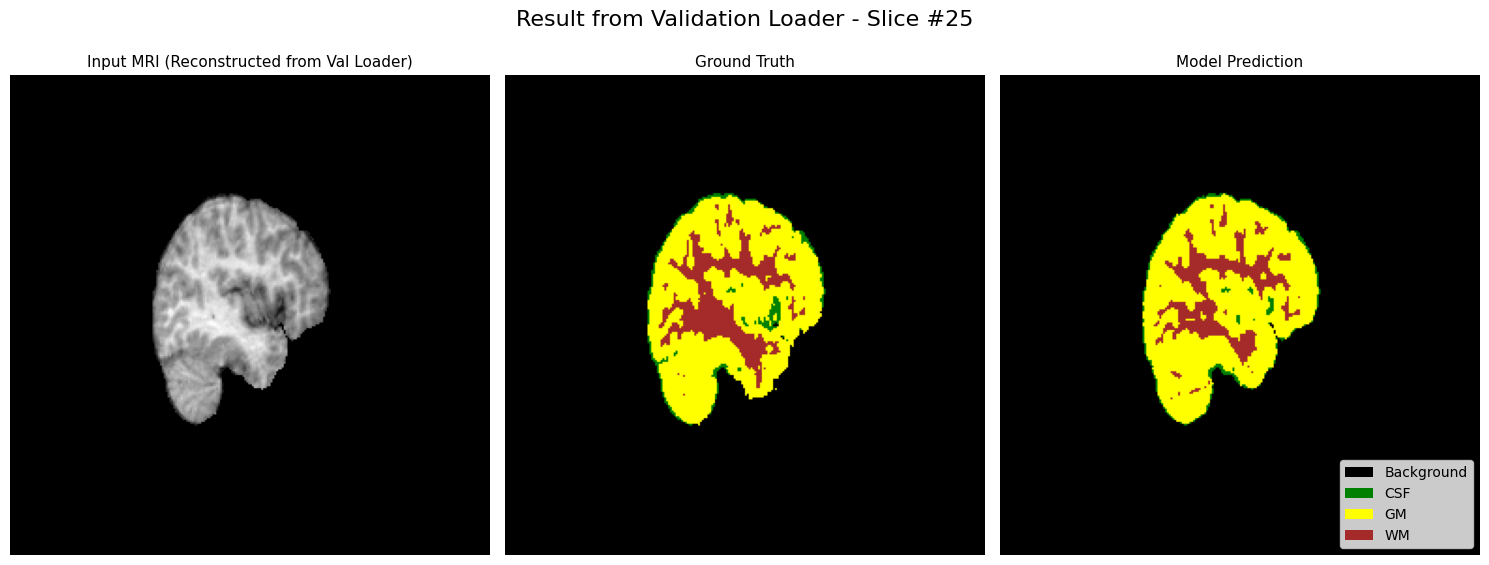

In [17]:
def visualize_prediction_from_loader(loader, model):
    model.eval()
    dataset = loader.dataset

    total_slices = len(dataset) // 4

    while True:
        slice_idx = random.randint(0, total_slices - 1)
        start_patch_idx = slice_idx * 4

        temp_mask_sum = 0
        for i in range(4):
            _, m = dataset[start_patch_idx + i]
            temp_mask_sum += torch.sum(m).item()

        if temp_mask_sum > 2000:
            break

    print(f"Slice number {slice_idx}, patches: {start_patch_idx} to {start_patch_idx+3}\n")

    patches_img = []
    patches_mask = []
    patches_pred = []

    with torch.no_grad():
        for i in range(4):
            img_tensor, mask_tensor = dataset[start_patch_idx + i]

            input_batch = img_tensor.unsqueeze(0).to(device)

            output = model(input_batch)
            pred_class = torch.argmax(output, dim=1) # [1, 128, 128]

            patches_img.append(img_tensor.squeeze().numpy())
            patches_mask.append(mask_tensor.squeeze().numpy())
            patches_pred.append(pred_class.squeeze().cpu().numpy())


    def stitch(list_of_patches):
        top = np.concatenate((list_of_patches[0], list_of_patches[1]), axis=1)
        bot = np.concatenate((list_of_patches[2], list_of_patches[3]), axis=1)
        full = np.concatenate((top, bot), axis=0)
        return full

    full_img = stitch(patches_img)
    full_mask = stitch(patches_mask)
    full_pred = stitch(patches_pred)


    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(f"Result from Validation Loader - Slice #{slice_idx}", fontsize=16)

    axes[0].imshow(full_img, cmap='gray')
    axes[0].set_title("Input MRI (Reconstructed from Val Loader)", fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(full_mask, cmap=cmap, norm=norm)
    axes[1].set_title("Ground Truth", fontsize=11)
    axes[1].axis('off')

    axes[2].imshow(full_pred, cmap=cmap, norm=norm)
    axes[2].set_title("Model Prediction", fontsize=11)
    axes[2].axis('off')

    axes[2].legend(handles=legend_elements, loc='lower right', fontsize=10)

    plt.tight_layout()
    plt.show()


visualize_prediction_from_loader(val_loader, model)